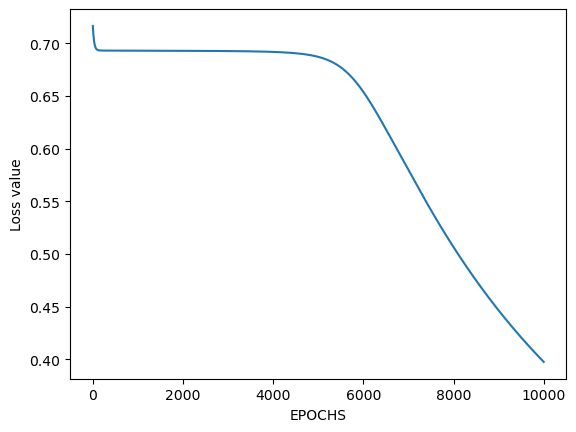

Input Output
[1, 0] 1
[1, 1] 0
[0, 1] 1
[0, 0] 0


In [1]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt

# Creates the input data
x = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])

# Defines the target/expected output
y = np.array([[0, 1, 1, 0]])

# Define network size
n_x = 2
n_y = 1
n_h = 2

# Number of training examples
m = x.shape[1]

# Learning rate
lr = 0.1

# Fix random number generation
np.random.seed(2)

# Initialize weights
w1 = np.random.rand(n_h, n_x)
w2 = np.random.rand(n_y, n_h)

# Store loss values
losses = []

# Sigmoid function
def sigmoid(z):
    z = 1 / (1 + np.exp(-z))
    return z

# Forward propagation
def forward_prop(w1, w2, x):
    z1 = np.dot(w1, x)
    a1 = sigmoid(z1)
    z2 = np.dot(w2, a1)
    a2 = sigmoid(z2)
    return z1, a1, z2, a2

# Backpropagation
def back_prop(m, w1, w2, z1, a1, z2, a2, y):
    dz2 = a2 - y
    dw2 = np.dot(dz2, a1.T) / m

    dz1 = np.dot(w2.T, dz2) * a1 * (1 - a1)
    dw1 = np.dot(dz1, x.T) / m

    dw1 = np.reshape(dw1, w1.shape)
    dw2 = np.reshape(dw2, w2.shape)

    return dz2, dw2, dz1, dw1

# Training iterations
iterations = 10000

for i in range(iterations):
    z1, a1, z2, a2 = forward_prop(w1, w2, x)

    loss = -(1 / m) * np.sum(
        y * np.log(a2) + (1 - y) * np.log(1 - a2)
    )
    losses.append(loss)

    da2, dw2, dz1, dw1 = back_prop(
        m, w1, w2, z1, a1, z2, a2, y
    )

    w2 = w2 - lr * dw2
    w1 = w1 - lr * dw1

# Plot loss
plt.plot(losses)
plt.xlabel("EPOCHS")
plt.ylabel("Loss value")
plt.show()

# Prediction function
def predict(w1, w2, input):
    z1, a1, z2, a2 = forward_prop(w1, w2, input)
    a2 = np.squeeze(a2)

    if a2 >= 0.5:
        print([i[0] for i in input], 1)
    else:
        print([i[0] for i in input], 0)

print("Input", "Output")

# Test Input (1,0)
test = np.array([[1], [0]])
predict(w1, w2, test)

# Test Input (1,1)
test = np.array([[1], [1]])
predict(w1, w2, test)

# Test Input (0,1)
test = np.array([[0], [1]])
predict(w1, w2, test)

# Test Input (0,0)
test = np.array([[0], [0]])
predict(w1, w2, test)